In [ ]:
import sqlite3
import random
import datetime
import pandas as pd




db_path = "big_sales.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id          INTEGER PRIMARY KEY AUTOINCREMENT,
    product     TEXT    NOT NULL,
    quantity    INTEGER NOT NULL,
    price       REAL    NOT NULL,
    sale_date   TEXT    NOT NULL      -- ISO date string: YYYY-MM-DD
)
""")
conn.commit()

In [3]:
import sqlite3
import random
import datetime


conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id         INTEGER PRIMARY KEY AUTOINCREMENT,
    product    TEXT    NOT NULL,
    quantity   INTEGER NOT NULL,
    price      REAL    NOT NULL,
    sale_date  TEXT    NOT NULL
)
""")
conn.commit()

In [4]:
products = ["Laptop","Smartwatch","fitband","Smart Ring","Tab"]
rows = []
for _ in range(150):
    prod = random.choice(products)
    qty = random.randint(1, 50)
    price = round(random.uniform(100.0, 1000.0), 2)  # adjusted price range
    dt = datetime.date(
        2025,
        random.randint(1, 12),
        random.randint(1, 28)
    ).isoformat()
    rows.append((prod, qty, price, dt))


cursor.executemany(
    "INSERT INTO sales (product, quantity, price, sale_date) VALUES (?,?,?,?)",
    rows
)


conn.commit()


cursor.execute("SELECT COUNT(*) FROM sales")
count = cursor.fetchone()[0]
print(f"Total rows in sales table: {count}")

conn.close()


Total rows in sales table: 150


Sales Summary:

      product  total_qty    revenue
0      Laptop       1023  479478.88
1  Smart Ring        899  528416.77
2  Smartwatch        821  428666.20
3         Tab        614  303179.96
4     Fitband        584  292782.93


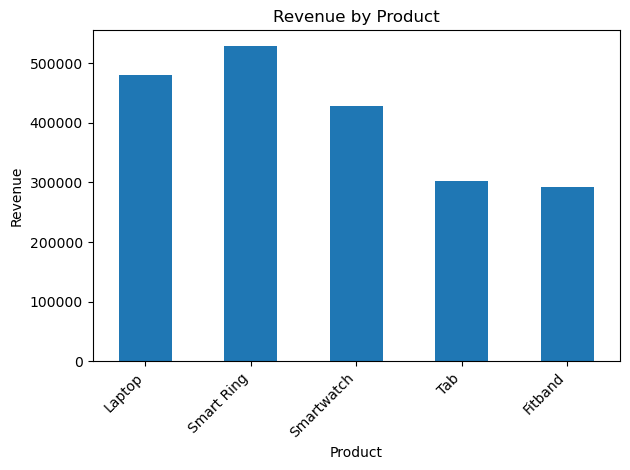

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


%matplotlib inline


conn = sqlite3.connect("sales_data.db")


query = """
SELECT 
    product, 
    SUM(quantity)    AS total_qty, 
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""
df = pd.read_sql_query(query, conn)
conn.close()


df['product'] = df['product'].str.title()


print("Sales Summary:\n", df, sep="\n")

# 5. Plot revenue by product
ax = df.plot(
    kind='bar',
    x='product',
    y='revenue',
    legend=False
)
ax.set_title("Revenue by Product")
ax.set_xlabel("Product")
ax.set_ylabel("Revenue")

# Rotate labels to fit longer names like "Smart Ring"
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("sales_chart.png")
plt.show()
